In [12]:
#pip install pandas

import pandas as pd

In [13]:
#pip install matplotlib

In [14]:
#pip install numpy

In [15]:
#pip install seaborn

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


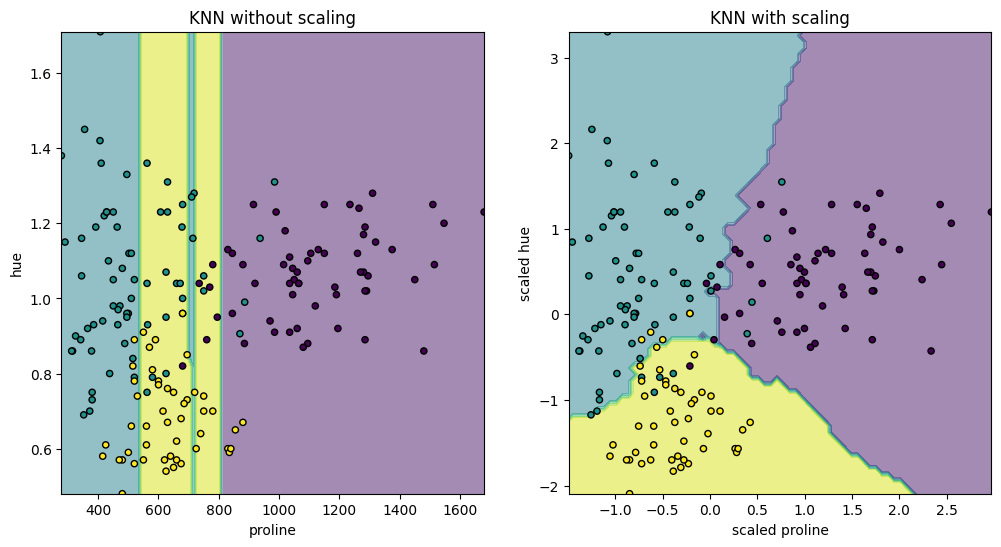

In [18]:
%pip install scikit-learn

from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_wine

# ensure a scaler exists for scaling (defined here to avoid NameError)
scaler = StandardScaler()

# If X and y are not already defined in the notebook, load the wine dataset
if 'X' not in globals() or 'y' not in globals():
    data = load_wine()
    X = pd.DataFrame(data.data, columns=data.feature_names)
    y = data.target

# Use the two features required for plotting
X_plot = X[["proline", "hue"]]

# scale and keep column names so downstream plotting (which expects a DataFrame) works
X_plot_scaled = pd.DataFrame(scaler.fit_transform(X_plot), columns=X_plot.columns)

clf = KNeighborsClassifier(n_neighbors=20)


def fit_and_plot_model(X_plot, y, clf, ax):
    clf.fit(X_plot, y)
    disp = DecisionBoundaryDisplay.from_estimator(
        clf,
        X_plot,
        response_method="predict",
        alpha=0.5,
        ax=ax,
    )
    disp.ax_.scatter(X_plot["proline"], X_plot["hue"], c=y, s=20, edgecolor="k")
    disp.ax_.set_xlim((X_plot["proline"].min(), X_plot["proline"].max()))
    disp.ax_.set_ylim((X_plot["hue"].min(), X_plot["hue"].max()))
    return disp.ax_


fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 6))

fit_and_plot_model(X_plot, y, clf, ax1)
ax1.set_title("KNN without scaling")

fit_and_plot_model(X_plot_scaled, y, clf, ax2)
ax2.set_xlabel("scaled proline")
ax2.set_ylabel("scaled hue")
_ = ax2.set_title("KNN with scaling")